# Поиск атипичных пациентов с циррозом с помощью Deep Autoencoder

В этом ноутбуке автоэнкодер используется не для прямой классификации `Status` или `Stage`,
а для поиска пациентов, чей профиль заметно отличается от референсной группы.

Идея: модель учится хорошо восстанавливать **типичный профиль более стабильных пациентов**,
а затем мы смотрим, у кого ошибка реконструкции заметно выше нормы.


## Что будет сделано

1. Загрузим датасет `cirrhosis_preprocessed.csv` и выберем безопасный набор признаков.
2. Проверим, почему `Status = 0` можно взять как референсную группу для обучения.
3. Разделим данные на `train` и `test`, а масштабирование выполним только по референсному `train`.
4. Обучим компактный deep autoencoder на пациентах из референсной группы.
5. Подберём порог атипичности по ошибке реконструкции на валидации.
6. Посмотрим, как атипичность распределяется по `Status`, `Stage` и по конкретным пациентам.


In [1]:
import copy
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
REFERENCE_STATUS = 0

def set_seed(seed: int = RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)

def resolve_data_path():
    candidates = [
        Path.cwd() / "cirrhosis_preprocessed.csv",
        Path.cwd().parent / "cirrhosis_preprocessed.csv",
        Path(r"D:/ProjectAI/ai_brief-main/cirrhosis_preprocessed.csv"),
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError("Не удалось найти cirrhosis_preprocessed.csv")

def hidden_activation(x):
    return np.tanh(x)

def reconstruction_errors(model, array_like):
    reconstructed = model.predict(array_like)
    errors = np.mean((reconstructed - np.asarray(array_like)) ** 2, axis=1)
    return errors, reconstructed

def encode_latent(model, array_like):
    hidden = np.asarray(array_like)
    for layer_idx in range(3):
        hidden = hidden @ model.coefs_[layer_idx] + model.intercepts_[layer_idx]
        hidden = hidden_activation(hidden)
    return hidden

set_seed()
DATA_PATH = resolve_data_path()
print(f"Датасет: {DATA_PATH}")
print("Реализация автоэнкодера: sklearn.neural_network.MLPRegressor")


Датасет: D:\ProjectAI\ai_brief-main\cirrhosis_preprocessed.csv
Реализация автоэнкодера: sklearn.neural_network.MLPRegressor


## Загрузка данных

Для поиска атипичности не будем использовать признаки, которые напрямую кодируют исход:

- `ID`
- `Status`
- `Stage` 
- `N_Days`
- `Age`


In [2]:
df = pd.read_csv(DATA_PATH)
df["Status"] = df["Status"].astype(int)
df["Stage"] = df["Stage"].astype(int)

drop_columns = ["ID", "Status", "Stage", "N_Days", "Age"]
feature_columns = [col for col in df.columns if col not in drop_columns]

if df[feature_columns].isna().sum().sum() > 0:
    df[feature_columns] = df[feature_columns].fillna(df[feature_columns].median(numeric_only=True))

display(df.head())
print(f"Размер датасета: {df.shape[0]} строк x {df.shape[1]} столбцов")
print(f"Число признаков для автоэнкодера: {len(feature_columns)}")
print("Используемые признаки:", feature_columns)
print(f"Всего пропусков после проверки: {int(df[feature_columns].isna().sum().sum())}")


,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,...,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Age_years
0,1,400,2,0.0,21464,0.0,1.0,1.0,1.0,2.0,...,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4,58.805479
1,2,4500,0,0.0,20617,0.0,0.0,1.0,1.0,0.0,...,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3,56.484932
2,3,1012,2,0.0,25594,1.0,0.0,0.0,0.0,1.0,...,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4,70.120548
3,4,1925,2,0.0,19994,0.0,0.0,1.0,1.0,1.0,...,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4,54.778082
4,5,1504,1,1.0,13918,0.0,0.0,1.0,1.0,0.0,...,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3,38.131507


Размер датасета: 312 строк x 21 столбцов
Число признаков для автоэнкодера: 16
Используемые признаки: ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Age_years']
Всего пропусков после проверки: 0


## Почему берём `Status = 0` как референс

Автоэнкодер ищет аномалии лучше всего, когда обучается на относительно однородной группе.
В нашем случае `Status = 0` — самая крупная группа, и по ключевым лабораторным показателям
она выглядит мягче остальных. Значит, её можно использовать как **эталон более типичного профиля**.


,count,share_%
Status,,
0,168,53.85
1,19,6.09
2,125,40.06


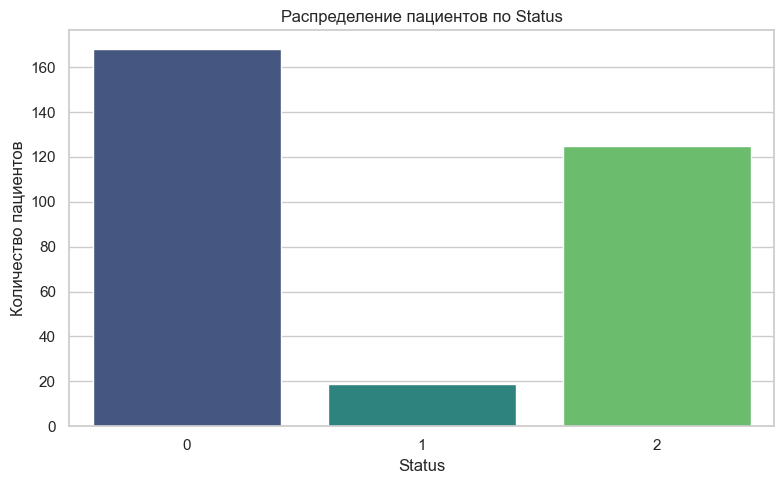

Bilirubin        Albumin         Copper        Prothrombin         \
            mean median    mean median    mean median        mean median   
Status                                                                     
0           1.50    0.9    3.63   3.63   66.65   52.0       10.38   10.2   
1           3.13    3.2    3.57   3.57  124.00  102.0       10.37   10.1   
2           5.63    3.2    3.36   3.43  134.91  111.0       11.24   11.0   

       Stage          N_Days          
        mean median     mean  median  
Status                                
0       2.75    3.0  2457.58  2309.5  
1       3.26    3.0  1508.21  1435.0  
2       3.38    4.0  1475.64  1191.0

Stage,1,2,3,4
Status,,,,
0,15,48,69,36
1,0,3,8,8
2,1,16,43,65


У группы Status=0 ниже средние Bilirubin, Copper и Stage, а N_Days выше. Это делает её хорошей референсной группой для обучения автоэнкодера.


In [3]:
status_distribution = pd.DataFrame(
    {
        "count": df["Status"].value_counts().sort_index(),
        "share_%": (df["Status"].value_counts(normalize=True).sort_index() * 100).round(2),
    }
)
display(status_distribution)

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x="Status", palette="viridis", ax=ax)
ax.set_title("Распределение пациентов по Status")
ax.set_xlabel("Status")
ax.set_ylabel("Количество пациентов")
plt.tight_layout()
plt.show()

reference_profile = (
    df.groupby("Status")[["Bilirubin", "Albumin", "Copper", "Prothrombin", "Stage", "N_Days"]]
    .agg(["mean", "median"])
    .round(2)
)
stage_status_table = pd.crosstab(df["Status"], df["Stage"])

display(reference_profile)
display(stage_status_table)

print(
    "У группы Status=0 ниже средние Bilirubin, Copper и Stage, а N_Days выше. "
    "Это делает её хорошей референсной группой для обучения автоэнкодера."
)


## Разделение на train / validation / test

1. Сначала делим весь датасет на `train` и `test`, сохраняя распределение `Status`.
2. Из `train` оставляем только пациентов `Status = 0`.
3. Эту референсную группу дополнительно делим на `ref_train` и `ref_val`.
4. `RobustScaler` обучаем только на `ref_train`, чтобы избежать утечки информации.


In [4]:
X = df[feature_columns].copy()
y_status = df["Status"].copy()
y_stage = df["Stage"].copy()

X_train_all, X_test, y_train_status, y_test_status, y_train_stage, y_test_stage = train_test_split(
    X,
    y_status,
    y_stage,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_status,
)

X_reference = X_train_all[y_train_status == REFERENCE_STATUS].copy()
X_ref_train, X_ref_val = train_test_split(
    X_reference,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

scaler = RobustScaler()
X_ref_train_scaled = scaler.fit_transform(X_ref_train)
X_ref_val_scaled = scaler.transform(X_ref_val)
X_test_scaled = scaler.transform(X_test)

X_test_reset = X_test.reset_index(drop=True).copy()
test_meta = df.loc[X_test.index, ["ID", "Status", "Stage"]].reset_index().rename(
    columns={"index": "dataset_index"}
)

split_summary = pd.DataFrame(
    [
        {"subset": "train_all", "rows": len(X_train_all)},
        {"subset": "reference_train", "rows": len(X_ref_train)},
        {"subset": "reference_val", "rows": len(X_ref_val)},
        {"subset": "test", "rows": len(X_test)},
    ]
)

display(split_summary)
display(
    pd.DataFrame(
        {
            "train_status_count": y_train_status.value_counts().sort_index(),
            "test_status_count": y_test_status.value_counts().sort_index(),
        }
    ).fillna(0).astype(int)
)

print(
    f"На обучение модели пошли только {len(X_ref_train)} пациентов из референсной группы Status=0; "
    f"валидация на {len(X_ref_val)} таких же пациентах нужна для выбора порога."
)


,subset,rows
0,train_all,249
1,reference_train,107
2,reference_val,27
3,test,63


,train_status_count,test_status_count
Status,,
0,134,34
1,15,4
2,100,25


На обучение модели пошли только 107 пациентов из референсной группы Status=0; валидация на 27 таких же пациентах нужна для выбора порога.


## Модель Deep Autoencoder

Здесь автоэнкодер реализован как симметричная глубокая нейросеть:

`input -> 12 -> 6 -> 2 -> 6 -> 12 -> input`

Мы обучаем её восстанавливать входные признаки самих же пациентв


In [5]:
hidden_layers = (12, 6, 2, 6, 12)
learning_rate = 1e-3
alpha = 1e-4
batch_size = min(16, len(X_ref_train_scaled))
max_epochs = 250
patience = 30

autoencoder = MLPRegressor(
    hidden_layer_sizes=hidden_layers,
    activation="tanh",
    solver="adam",
    alpha=alpha,
    batch_size=batch_size,
    learning_rate_init=learning_rate,
    max_iter=1,
    warm_start=True,
    shuffle=True,
    random_state=RANDOM_STATE,
)

print("Архитектура hidden layers:", hidden_layers)
print(
    f"Гиперпараметры: batch_size={batch_size}, learning_rate_init={learning_rate}, "
    f"alpha={alpha}, max_epochs={max_epochs}, patience={patience}"
)


Архитектура hidden layers: (12, 6, 2, 6, 12)
Гиперпараметры: batch_size=16, learning_rate_init=0.001, alpha=0.0001, max_epochs=250, patience=30


In [6]:
history_rows = []
best_val_loss = np.inf
best_epoch = 0
patience_left = patience
best_model = None

for epoch in range(1, max_epochs + 1):
    autoencoder.fit(X_ref_train_scaled, X_ref_train_scaled)

    train_reconstructed = autoencoder.predict(X_ref_train_scaled)
    val_reconstructed = autoencoder.predict(X_ref_val_scaled)

    train_loss = mean_squared_error(X_ref_train_scaled, train_reconstructed)
    val_loss = mean_squared_error(X_ref_val_scaled, val_reconstructed)

    history_rows.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
        }
    )

    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        best_epoch = epoch
        patience_left = patience
        best_model = copy.deepcopy(autoencoder)
    else:
        patience_left -= 1

    if epoch == 1 or epoch % 25 == 0:
        print(
            f"epoch={epoch:03d} | train_loss={train_loss:.5f} | "
            f"val_loss={val_loss:.5f} | patience_left={patience_left}"
        )

    if patience_left == 0:
        print(f"Ранняя остановка на эпохе {epoch}.")
        break

autoencoder = best_model
history_df = pd.DataFrame(history_rows)
display(history_df.tail())


epoch=001 | train_loss=1.41710 | val_loss=1.87396 | patience_left=30
epoch=025 | train_loss=0.92352 | val_loss=1.32407 | patience_left=30


epoch=050 | train_loss=0.77026 | val_loss=1.14126 | patience_left=30
epoch=075 | train_loss=0.66764 | val_loss=1.07432 | patience_left=30


epoch=100 | train_loss=0.60351 | val_loss=1.02663 | patience_left=30
epoch=125 | train_loss=0.56047 | val_loss=0.97633 | patience_left=30


epoch=150 | train_loss=0.53787 | val_loss=0.95871 | patience_left=29
epoch=175 | train_loss=0.52316 | val_loss=0.95575 | patience_left=30


epoch=200 | train_loss=0.51144 | val_loss=0.94421 | patience_left=30
epoch=225 | train_loss=0.50061 | val_loss=0.92187 | patience_left=30


epoch=250 | train_loss=0.49121 | val_loss=0.90029 | patience_left=30


,epoch,train_loss,val_loss
245,246,0.492733,0.905305
246,247,0.491690,0.903408
247,248,0.491935,0.902695
248,249,0.491446,0.900457
249,250,0.491207,0.900295


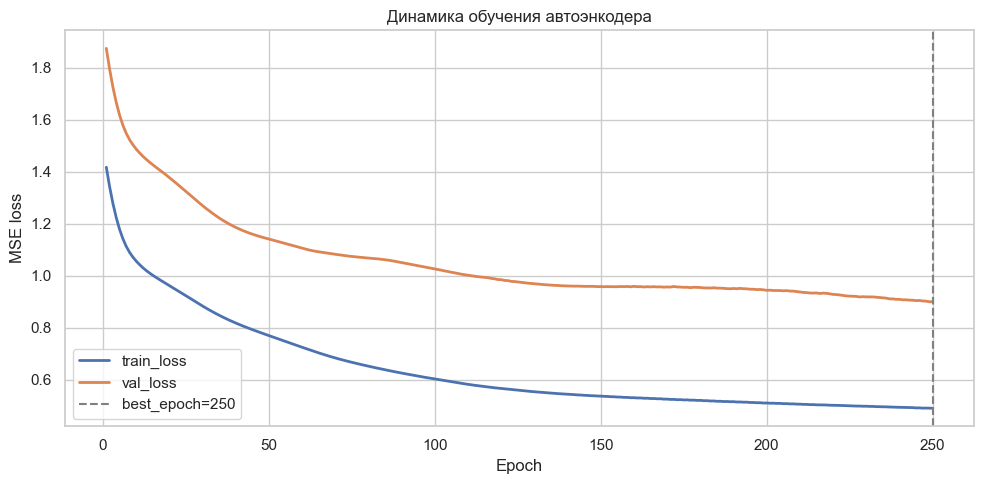

Лучшая эпоха: 250. Train loss = 0.49121, validation loss = 0.90029.
Кривая нужна не для классификации, а чтобы убедиться, что модель стабильно учит структуру референсной группы.


In [7]:
plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss", linewidth=2)
plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss", linewidth=2)
plt.axvline(best_epoch, color="gray", linestyle="--", label=f"best_epoch={best_epoch}")
plt.title("Динамика обучения автоэнкодера")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.tight_layout()
plt.show()

best_train_loss = history_df.loc[history_df["epoch"] == best_epoch, "train_loss"].iloc[0]
print(
    f"Лучшая эпоха: {best_epoch}. "
    f"Train loss = {best_train_loss:.5f}, validation loss = {best_val_loss:.5f}."
)
print("Кривая нужна не для классификации, а чтобы убедиться, что модель стабильно учит структуру референсной группы.")


## Ошибка реконструкции и порог атипичности

Сначала считаем ошибку реконструкции на `ref_val` — это честная проверка на пациентах той же
референсной группы, которых модель не видела на обучении. Затем берём `95-й перцентиль`
этих ошибок как порог атипичности.


In [8]:
ref_val_errors, _ = reconstruction_errors(autoencoder, X_ref_val_scaled)
test_errors, _ = reconstruction_errors(autoencoder, X_test_scaled)

threshold = float(np.quantile(ref_val_errors, 0.95))

errors_df = test_meta.copy()
errors_df["reconstruction_error"] = test_errors
errors_df["is_atypical"] = errors_df["reconstruction_error"] > threshold

error_summary_status = (
    errors_df.groupby("Status")["reconstruction_error"]
    .agg(["count", "mean", "median", "max"])
    .round(4)
)
error_summary_stage = (
    errors_df.groupby("Stage")["reconstruction_error"]
    .agg(["count", "mean", "median", "max"])
    .round(4)
)

display(pd.DataFrame({"ref_val_error": ref_val_errors}).describe().round(4))
display(error_summary_status)
display(error_summary_stage)

print(f"Порог атипичности = {threshold:.4f} (95-й перцентиль ошибки на ref_val).")
print(
    f"На тестовой выборке атипичными отмечены {errors_df['is_atypical'].sum()} из {len(errors_df)} пациентов "
    f"({errors_df['is_atypical'].mean() * 100:.1f}%)."
)
print(
    f"Медианная ошибка выросла с {error_summary_status.loc[0, 'median']:.4f} у Status=0 "
    f"до {error_summary_status.loc[2, 'median']:.4f} у Status=2."
)
print(
    f"По Stage медианная ошибка выросла с {error_summary_stage.loc[1, 'median']:.4f} на Stage=1 "
    f"до {error_summary_stage.loc[4, 'median']:.4f} на Stage=4."
)


,ref_val_error
count,27.0000
mean,0.9003
std,1.3650
min,0.0892
25%,0.2859
50%,0.3712
75%,0.7498
max,5.4738


,count,mean,median,max
Status,,,,
0,34,0.5614,0.3368,5.2963
1,4,1.6416,0.5621,4.9627
2,25,2.9221,1.9697,27.2204


,count,mean,median,max
Stage,,,,
1,3,0.2338,0.2261,0.2664
2,11,0.3895,0.3547,0.8232
3,22,1.2118,0.4933,4.9627
4,27,2.4838,1.2579,27.2204


Порог атипичности = 4.1323 (95-й перцентиль ошибки на ref_val).
На тестовой выборке атипичными отмечены 5 из 63 пациентов (7.9%).
Медианная ошибка выросла с 0.3368 у Status=0 до 1.9697 у Status=2.
По Stage медианная ошибка выросла с 0.2261 на Stage=1 до 1.2579 на Stage=4.


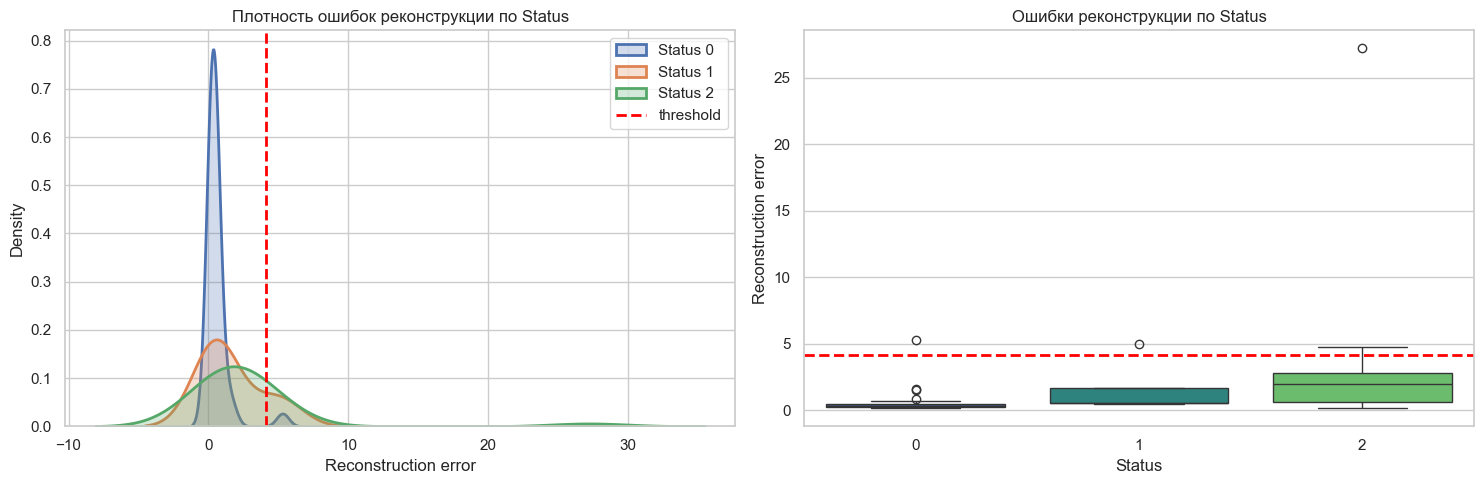

Если распределения для более тяжёлых групп заметно смещаются вправо, значит автоэнкодер действительно ловит отклонение от референсного профиля.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for status_value in sorted(errors_df["Status"].unique()):
    current = errors_df.loc[errors_df["Status"] == status_value, "reconstruction_error"]
    if len(current) > 1 and np.std(current) > 0:
        sns.kdeplot(current, fill=True, alpha=0.25, linewidth=2, ax=axes[0], label=f"Status {status_value}")

axes[0].axvline(threshold, color="red", linestyle="--", linewidth=2, label="threshold")
axes[0].set_title("Плотность ошибок реконструкции по Status")
axes[0].set_xlabel("Reconstruction error")
axes[0].legend()

sns.boxplot(data=errors_df, x="Status", y="reconstruction_error", palette="viridis", ax=axes[1])
axes[1].axhline(threshold, color="red", linestyle="--", linewidth=2)
axes[1].set_title("Ошибки реконструкции по Status")
axes[1].set_xlabel("Status")
axes[1].set_ylabel("Reconstruction error")

plt.tight_layout()
plt.show()

print(
    "Если распределения для более тяжёлых групп заметно смещаются вправо, "
    "значит автоэнкодер действительно ловит отклонение от референсного профиля."
)


## Насколько атипичность связана со Status и Stage

Это не формальная метрика качества модели, а клиническая sanity check:
если доля атипичных случаев растёт вместе с тяжестью статуса или стадии,
то сигнал автоэнкодера выглядит правдоподобно.


,atypical_rate_%
Status,
0,2.94
1,25.00
2,12.00


,atypical_rate_%
Stage,
1,0.00
2,0.00
3,13.64
4,7.41


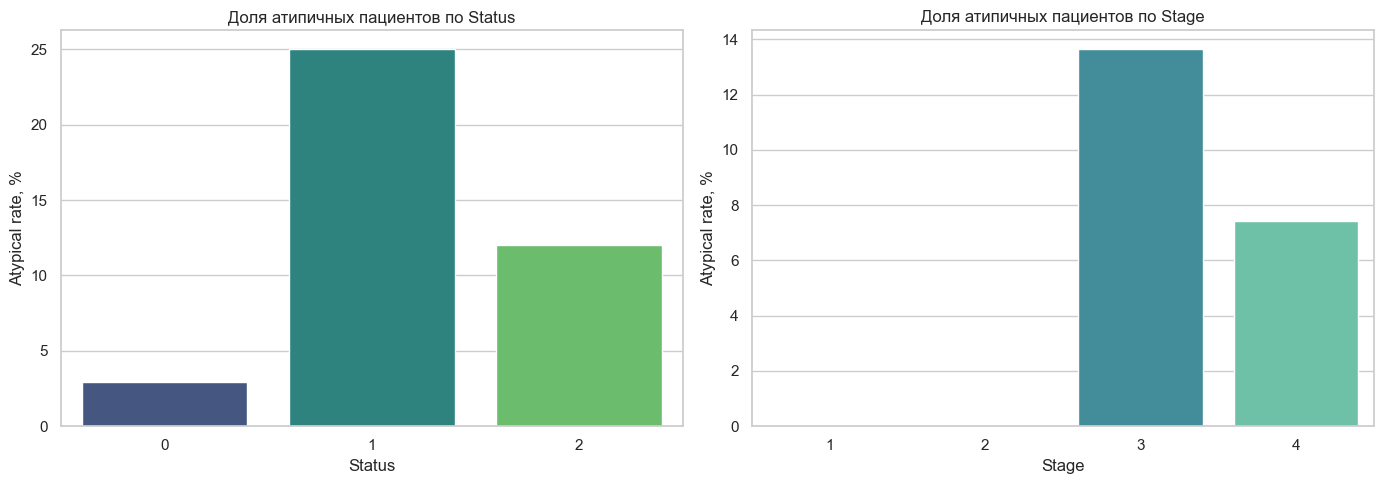

Доли атипичных случаев выше в тяжёлых группах по сравнению с референсом, но рост не строго монотонный. Для маленьких подгрупп это нормально: порог здесь консервативный, а тяжёлые пациенты сами по себе неоднородны.


In [10]:
atypical_rate_by_status = (
    errors_df.groupby("Status")["is_atypical"]
    .mean()
    .mul(100)
    .round(2)
    .rename("atypical_rate_%")
    .to_frame()
)
atypical_rate_by_stage = (
    errors_df.groupby("Stage")["is_atypical"]
    .mean()
    .mul(100)
    .round(2)
    .rename("atypical_rate_%")
    .to_frame()
)

display(atypical_rate_by_status)
display(atypical_rate_by_stage)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=atypical_rate_by_status.reset_index(), x="Status", y="atypical_rate_%", palette="viridis", ax=axes[0])
axes[0].set_title("Доля атипичных пациентов по Status")
axes[0].set_ylabel("Atypical rate, %")

sns.barplot(data=atypical_rate_by_stage.reset_index(), x="Stage", y="atypical_rate_%", palette="mako", ax=axes[1])
axes[1].set_title("Доля атипичных пациентов по Stage")
axes[1].set_ylabel("Atypical rate, %")

plt.tight_layout()
plt.show()

print(
    "Доли атипичных случаев выше в тяжёлых группах по сравнению с референсом, "
    "но рост не строго монотонный. Для маленьких подгрупп это нормально: порог здесь консервативный, "
    "а тяжёлые пациенты сами по себе неоднородны."
)


## Латентное пространство

У автоэнкодера есть двухмерное узкое место. Оно удобно тем, что можно посмотреть,
как пациенты располагаются в этом компактном представлении и где оказываются атипичные случаи.


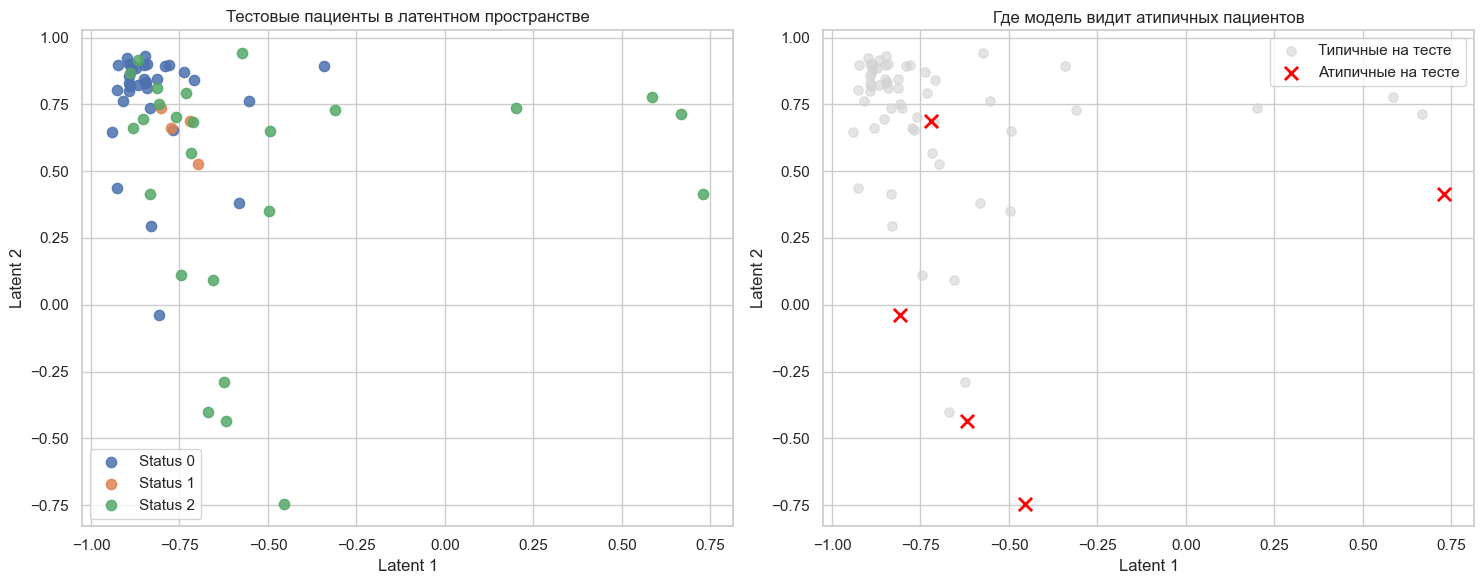

Обычно атипичные пациенты уходят на периферию латентного пространства или формируют отдельные компактные группы.


In [11]:
latent_test = encode_latent(autoencoder, X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for status_value in sorted(errors_df["Status"].unique()):
    mask = errors_df["Status"].to_numpy() == status_value
    axes[0].scatter(
        latent_test[mask, 0],
        latent_test[mask, 1],
        s=55,
        alpha=0.85,
        label=f"Status {status_value}",
    )
axes[0].set_title("Тестовые пациенты в латентном пространстве")
axes[0].set_xlabel("Latent 1")
axes[0].set_ylabel("Latent 2")
axes[0].legend()

anomaly_mask = errors_df["is_atypical"].to_numpy()
axes[1].scatter(
    latent_test[~anomaly_mask, 0],
    latent_test[~anomaly_mask, 1],
    s=45,
    alpha=0.6,
    color="lightgray",
    label="Типичные на тесте",
)
axes[1].scatter(
    latent_test[anomaly_mask, 0],
    latent_test[anomaly_mask, 1],
    s=90,
    marker="x",
    linewidth=2,
    color="red",
    label="Атипичные на тесте",
)
axes[1].set_title("Где модель видит атипичных пациентов")
axes[1].set_xlabel("Latent 1")
axes[1].set_ylabel("Latent 2")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Обычно атипичные пациенты уходят на периферию латентного пространства или формируют отдельные компактные группы.")


## Самые атипичные пациенты

Здесь полезнее смотреть не только на ошибку, но и на реальные клинические признаки,
которые могли сделать пациента нетипичным относительно референсной группы.


In [12]:
detailed_test_df = pd.concat([test_meta.reset_index(drop=True), X_test_reset.reset_index(drop=True)], axis=1)
detailed_test_df["reconstruction_error"] = errors_df["reconstruction_error"].values
detailed_test_df["is_atypical"] = errors_df["is_atypical"].values

top_atypical_patients = (
    detailed_test_df.sort_values("reconstruction_error", ascending=False)
    .loc[:, ["ID", "Status", "Stage", "Bilirubin", "Albumin", "Copper", "Platelets", "Prothrombin", "Age_years", "reconstruction_error"]]
    .head(10)
    .round(3)
)
display(top_atypical_patients)

profile_features = ["Bilirubin", "Albumin", "Copper", "Platelets", "Prothrombin", "Age_years"]
typical_profile = detailed_test_df.loc[~detailed_test_df["is_atypical"], profile_features].median()
atypical_profile = detailed_test_df.loc[detailed_test_df["is_atypical"], profile_features].median()

profile_comparison = pd.DataFrame(
    {
        "typical_test_median": typical_profile,
        "atypical_test_median": atypical_profile,
        "delta": (atypical_profile - typical_profile),
    }
).round(3)
display(profile_comparison)

severe_share = (
    top_atypical_patients["Stage"].ge(3).mean() * 100
    if len(top_atypical_patients) > 0 else np.nan
)

print(
    "Эта таблица помогает увидеть не просто 'кто необычный', "
    "а в какую сторону его профиль уходит относительно типичных пациентов."
)
print(
    f"Среди top-10 атипичных пациентов {severe_share:.1f}% имеют Stage >= 3: "
    "модель в основном поднимает действительно тяжёлые или нетипичные профили."
)


,ID,Status,Stage,Bilirubin,Albumin,Copper,Platelets,Prothrombin,Age_years,reconstruction_error
54,191,2,4,24.5,3.35,233.0,399.0,15.2,52.729,27.220
22,293,0,4,8.5,2.98,196.0,122.0,12.3,57.236,5.296
61,120,1,3,3.5,3.98,444.0,344.0,10.6,35.175,4.963
58,35,2,3,1.2,3.20,201.0,431.0,10.6,48.652,4.756
37,187,2,3,14.0,3.43,251.0,268.0,11.5,35.816,4.392
5,78,2,4,6.3,3.02,75.0,236.0,10.6,47.978,3.958
27,164,2,4,8.5,3.34,161.0,88.0,13.3,43.444,3.720
11,80,2,4,7.2,3.72,269.0,360.0,11.2,67.458,3.239
43,300,2,4,5.2,2.23,234.0,206.0,12.3,58.211,2.793
7,148,2,3,7.2,3.26,247.0,330.0,9.8,30.885,2.510


,typical_test_median,atypical_test_median,delta
Bilirubin,1.200,8.500,7.300
Albumin,3.555,3.350,-0.205
Copper,66.000,233.000,167.000
Platelets,258.000,344.000,86.000
Prothrombin,10.600,11.500,0.900
Age_years,49.927,48.652,-1.275


Эта таблица помогает увидеть не просто 'кто необычный', а в какую сторону его профиль уходит относительно типичных пациентов.
Среди top-10 атипичных пациентов 100.0% имеют Stage >= 3: модель в основном поднимает действительно тяжёлые или нетипичные профили.


In [13]:
median_error_status0 = error_summary_status.loc[0, "median"] if 0 in error_summary_status.index else np.nan
median_error_status2 = error_summary_status.loc[2, "median"] if 2 in error_summary_status.index else np.nan
atypical_rate_status0 = atypical_rate_by_status.loc[0, "atypical_rate_%"] if 0 in atypical_rate_by_status.index else np.nan
atypical_rate_status2 = atypical_rate_by_status.loc[2, "atypical_rate_%"] if 2 in atypical_rate_by_status.index else np.nan

print("Краткий итог:")
print(
    f"- Автоэнкодер обучен на референсной группе Status=0 и использует порог {threshold:.4f} "
    "по ошибке реконструкции."
)
print(
    f"- Медианная ошибка выросла с {median_error_status0:.4f} у Status=0 "
    f"до {median_error_status2:.4f} у Status=2."
)
print(
    f"- Доля атипичных пациентов выросла с {atypical_rate_status0:.1f}% "
    f"у Status=0 до {atypical_rate_status2:.1f}% у Status=2."
)
print(
    "- Значит, модель улавливает отклонение от более стабильного клинического профиля "
    "и может использоваться как инструмент поиска нетипичных пациентов для дополнительного разбора."
)
print(
    "- При этом атипичность не равна диагнозу: это повод внимательно посмотреть на кейс, "
    "а не автоматический медицинский вывод."
)


Краткий итог:
- Автоэнкодер обучен на референсной группе Status=0 и использует порог 4.1323 по ошибке реконструкции.
- Медианная ошибка выросла с 0.3368 у Status=0 до 1.9697 у Status=2.
- Доля атипичных пациентов выросла с 2.9% у Status=0 до 12.0% у Status=2.
- Значит, модель улавливает отклонение от более стабильного клинического профиля и может использоваться как инструмент поиска нетипичных пациентов для дополнительного разбора.
- При этом атипичность не равна диагнозу: это повод внимательно посмотреть на кейс, а не автоматический медицинский вывод.
